## Explainability & Monitoring
This notebook provides explainability, diagnostics, and monitoring tools for the hybrid recommender system.
It uses the artefacts generated in earlier stages to analyse why recommendations are produced and how the system behaves over time.

### 1. Overview
This stage focuses on:

- Understanding why the model recommends specific items

- Analysing latent factor contributions (ALS)

- Inspecting content-based similarity

- Combining signals into a hybrid explanation

- Monitoring cold-start behaviour, interaction sparsity, and override events

---
## 1. Loading Artefacts
The notebook begins by loading the sparse user–item interaction matrix, which forms the foundation for all explainability and monitoring tasks. Alongside this, the aligned item metadata is imported, containing indexed item identifiers and aggregated raw text fields used for content modelling.
To ensure consistent indexing across all components, the user and item ID mappings are also loaded.

The saved ALS latent factor matrices are then reattached to a reconstructed ALS model object. This allows the notebook to generate collaborative filtering explanations without running the training process again.
Finally, the TF‑IDF vectoriser and the corresponding sparse matrix of item text features are loaded, ensuring that content-based similarity and term‑level explanations match the original training environment.

In [ ]:
"""
Load trained recommendation artefacts for explainability and monitoring analysis.

This notebook loads the processed interaction data, aligned item metadata,
trained ALS latent factors, and TF-IDF artefacts created in earlier stages
of the pipeline. These resources are then used to support explainability,
diagnostic checks, and monitoring of recommendation behaviour.
"""

# ============================================================
# 03_explainability_and_monitoring.ipynb
# - Explainability for ALS, content-based, and hybrid models
# - Category-based reasoning
# - Monitoring signals such as precision drift, cold-start behaviour,
#   and manual overrides
# - Diagnostic utilities
# ============================================================

import pickle

import implicit
import implicit.als
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# 1. LOAD ARTEFACTS
# ------------------------------------------------------------

# Load the sparse user-item interaction matrix prepared in the data
# preparation stage. This matrix provides the interaction history used
# for explainability, diagnostics, and monitoring analysis.
interactions = sparse.load_npz("artifacts/interactions.npz")

# Load the aligned item table containing indexed item identifiers and
# aggregated text features used by the content-based component.
items = pd.read_csv("artifacts/items_aligned.csv")

# Load the user identifier to index mapping so that raw user IDs can be
# matched to the indexed representation used throughout the pipeline.
with open("artifacts/user_id_to_idx.pkl", "rb") as f:
    user_id_to_idx = pickle.load(f)

# Load the item identifier to index mapping so that raw item IDs can be
# matched to the indexed representation used throughout the pipeline.
with open("artifacts/item_id_to_idx.pkl", "rb") as f:
    item_id_to_idx = pickle.load(f)

# ------------------------------------------------------------
# 2. LOAD SAVED ALS LATENT FACTORS
# ------------------------------------------------------------

# Load the saved ALS item and user latent factor matrices generated in
# the training notebook. These matrices are used to reconstruct the
# trained collaborative filtering model without retraining.
item_factors = np.load("artifacts/als_item_factors.npy")
user_factors = np.load("artifacts/als_user_factors.npy")

# Rebuild an ALS model object and assign the previously learned latent
# factors so that the model can be reused for analysis and explanation.
als_model = implicit.als.AlternatingLeastSquares(
    factors=item_factors.shape[1]
)
als_model.item_factors = item_factors
als_model.user_factors = user_factors

# Print the factor matrix dimensions to confirm that the ALS artefacts
# were loaded and reconstructed successfully.
print("Loaded ALS item_factors:", als_model.item_factors.shape)
print("Loaded ALS user_factors:", als_model.user_factors.shape)

# ------------------------------------------------------------
# 3. LOAD SAVED TF-IDF ARTEFACTS
# ------------------------------------------------------------

# Load the fitted TF-IDF vectoriser so that the same vocabulary and term
# weighting scheme can be reused during explainability analysis.
tfidf = pickle.load(open("artifacts/tfidf_vectorizer.pkl", "rb"))

# Load the sparse TF-IDF matrix containing content representations for
# the indexed item set.
tfidf_matrix = sparse.load_npz("artifacts/tfidf_matrix.npz")

# Extract the interaction matrix dimensions for later validation and use
# in monitoring or diagnostic routines.
n_users, n_items = interactions.shape

D:\UWE YEAR 3\Digital Systems Project\forecasting\lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


Loaded ALS item_factors: (1407580, 64)
Loaded ALS user_factors: (235061, 64)


## 2. Explainability Functions
A set of functions is provided to explain recommendations from different angles.

TF‑IDF Term Explanation
The TF‑IDF explanation identifies the most important terms associated with an item. By extracting the highest‑weighted features from the item’s TF‑IDF vector, the notebook reveals the semantic characteristics that define the item.

ALS Latent Factor Explanation
The ALS explanation focuses on collaborative filtering. It computes the element‑wise product of a user’s latent factor vector and an item’s latent factor vector. The largest values indicate the latent dimensions that contributed most strongly to the predicted score, offering insight into behavioural patterns.

Content-Based Explanation
The content-based explanation compares the recommended item with items the user has previously interacted with. Cosine similarity between TF‑IDF vectors identifies which historical items are most similar to the recommended one. This shows how the content model reasons about user preferences.

Hybrid Explanation
The hybrid explanation combines all three components - ALS factors, content similarity, and TF‑IDF terms - into a single structured output. It also includes the hybrid weighting parameter α, making it clear how much influence each model component had on the final recommendation.

In [ ]:
def top_tfidf_terms(item_idx, top_n=10):
    """
    Return the highest-weighted TF-IDF terms for a given item.

    The item's TF-IDF row is extracted from the sparse matrix, converted
    to a dense vector, and ranked in descending order of term weight.
    The corresponding vocabulary terms and scores are then returned.

    Parameters
    ----------
    item_idx : int
        Internal item index used in the TF-IDF matrix.
    top_n : int, default=10
        Number of top-ranked terms to return.

    Returns
    -------
    list[tuple[str, float]]
        List of term-score pairs ordered by descending TF-IDF weight.
    """
    # Extract the TF-IDF vector for the selected item as a dense array.
    row = tfidf_matrix[item_idx].toarray().ravel()

    # Identify the indices of the highest-weighted terms.
    top_indices = row.argsort()[-top_n:][::-1]

    # Map term indices back to vocabulary strings and retrieve scores.
    terms = np.array(tfidf.get_feature_names_out())[top_indices]
    scores = row[top_indices]

    return list(zip(terms, scores))


def explain_als(user_idx, item_idx, top_n=5):
    """
    Explain an ALS recommendation using latent factor contributions.

    The explanation is produced by multiplying the selected user's latent
    factor vector with the selected item's latent factor vector. The
    largest element-wise products indicate the latent dimensions that
    contributed most strongly to the final score.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    top_n : int, default=5
        Number of strongest latent factor contributions to return.

    Returns
    -------
    list[tuple[int, float]]
        List of latent factor indices and contribution values, ordered
        by descending contribution strength.
    """
    # Retrieve the latent factor vectors for the selected user and item.
    u_vec = als_model.user_factors[user_idx]
    i_vec = als_model.item_factors[item_idx]

    # Compute element-wise contribution of each latent factor.
    contributions = u_vec * i_vec
    top = contributions.argsort()[-top_n:][::-1]

    return [(int(f), float(contributions[f])) for f in top]


def explain_content(user_idx, item_idx, top_n=5):
    """
    Explain a content-based recommendation using item similarity.

    The selected item is compared against items previously interacted
    with by the user using cosine similarity over TF-IDF features. The
    most similar historical items are returned as the explanation.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    top_n : int, default=5
        Number of most similar historical items to return.

    Returns
    -------
    list[tuple[int, float]]
        List of historical item indices and similarity scores, ordered
        by descending cosine similarity. An empty list is returned if
        the user has no prior interactions.
    """
    # Retrieve the set of items previously interacted with by the user.
    user_row = interactions[user_idx]
    liked = user_row.indices

    # No explanation can be produced if no interaction history exists.
    if len(liked) == 0:
        return []

    # Compute cosine similarity between the selected item and the user's
    # previously interacted items in the TF-IDF feature space.
    sims = cosine_similarity(tfidf_matrix[item_idx], tfidf_matrix[liked]).ravel()
    top = sims.argsort()[-top_n:][::-1]

    return [(int(liked[i]), float(sims[i])) for i in top]

In [ ]:
def explain_hybrid(user_idx, item_idx, alpha=0.7):
    """
    Explain a hybrid recommendation using both collaborative and
    content-based signals.

    The explanation combines latent factor contributions from the ALS
    model with content-based similarity evidence derived from previously
    interacted items. It also includes the most important TF-IDF terms
    associated with the recommended item.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    alpha : float, default=0.7
        Weight assigned to the ALS component in the hybrid model.

    Returns
    -------
    dict
        Dictionary containing the recommended item index, ALS factor
        contributions, similar historical items from the content-based
        explanation, top TF-IDF terms for the item, and the hybrid
        weighting parameter.
    """
    # Retrieve the collaborative explanation based on ALS latent factors.
    als_part = explain_als(user_idx, item_idx)

    # Retrieve the content-based explanation based on similarity to the
    # user's previously interacted items.
    content_part = explain_content(user_idx, item_idx)

    # Retrieve the most important TF-IDF terms associated with the item.
    tfidf_terms = top_tfidf_terms(item_idx)

    # Return the combined explanation in a structured format.
    return {
        "item_idx": item_idx,
        "als_factors": als_part,
        "content_similar_items": content_part,
        "top_tfidf_terms": tfidf_terms,
        "alpha": alpha,
    }

## 3. Category Extraction
Some items contain embedded numeric tokens in their raw text fields, representing category identifiers. A helper function extracts these values and returns a small subset for readability. This supports category‑based reasoning and helps identify whether recommendations align with expected item categories.

In [ ]:

def get_item_categories(item_idx):
    """
    Extract category IDs from raw_text (if present).
    """
    text = items.loc[item_idx, "raw_text"]
    cats = [int(tok) for tok in text.split() if tok.isdigit()]
    return cats[:5]  # limit for readability


In [ ]:
def get_item_categories(item_idx):
    """
    Extract category identifiers from an item's raw text field.

    The raw text representation may contain numeric tokens that correspond
    to category identifiers. This function selects those numeric tokens,
    converts them to integers, and returns a limited subset for readability.

    Parameters
    ----------
    item_idx : int
        Internal item index used in the aligned items table.

    Returns
    -------
    list[int]
        List of extracted category identifiers, limited to the first
        five detected values.
    """
    # Retrieve the aggregated raw text associated with the selected item.
    text = items.loc[item_idx, "raw_text"]

    # Extract numeric tokens only, as these are treated as category IDs.
    cats = [int(tok) for tok in text.split() if tok.isdigit()]

    # Limit the returned list to improve readability in explanations.
    return cats[:5]

## 4. Cold‑Start Detection
Two diagnostic functions identify cold‑start users and cold‑start items.
A user is considered cold‑start if they have no recorded interactions, while an item is cold‑start if no users have interacted with it.
These checks are essential for understanding where collaborative filtering may struggle and where content-based methods become more important.

In [ ]:
def is_cold_start_user(user_idx):
    """
    Determine whether a user is a cold-start user.

    A user is treated as cold-start when no interactions are present
    in the user-item interaction matrix.

    Parameters
    ----------
    user_idx : int
        Internal user index.

    Returns
    -------
    bool
        True if the user has no recorded interactions, otherwise False.
    """
    return interactions[user_idx].nnz == 0


def is_cold_start_item(item_idx):
    """
    Determine whether an item is a cold-start item.

    An item is treated as cold-start when no user interactions are present
    for that item in the user-item interaction matrix.

    Parameters
    ----------
    item_idx : int
        Internal item index.

    Returns
    -------
    bool
        True if the item has no recorded interactions, otherwise False.
    """
    return interactions[:, item_idx].nnz == 0

## 5. Override Logging
The notebook includes a lightweight mechanism for recording override events. An override occurs when the system recommends one item but the user selects another. Each override is stored with the user index, the recommended item, and the chosen item.
Analysing these logs can reveal preference drift, mismatches between model predictions and user intent, and patterns of manual selection.

In [ ]:
# Store override events for later analysis of recommendation acceptance
# and manual user choice behaviour.
override_log = []


def log_override(user_idx, recommended_item, chosen_item):
    """
    Record an override event when a recommended item is not selected.

    An override is logged when a user is shown one recommended item but
    chooses a different item instead. These records can later be used
    to analyse recommendation mismatches, preference drift, or manual
    selection patterns.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    recommended_item : int
        Item index that was recommended by the system.
    chosen_item : int
        Item index actually selected instead of the recommendation.

    Returns
    -------
    None
        The override event is appended to the in-memory override log.
    """
    override_log.append(
        {
            "user_idx": user_idx,
            "recommended_item": recommended_item,
            "chosen_item": chosen_item,
        }
    )

## 6. Visual Explanation Tools
Several visualisation functions are provided to make explanations more intuitive.

- `TF‑IDF Term Importance Plot`:
This plot displays the most important terms for an item, helping to interpret its semantic meaning.

- `ALS Factor Contribution Plot`:
This visualisation highlights the latent factors with the strongest contribution to a recommendation, making the collaborative filtering process more transparent.

- `Content Similarity Plot`:
This plot shows the historical items most similar to the recommended item, illustrating how the content model reasons about user preferences.

- `Hybrid Explanation Plot`:
A combined three‑panel figure presents ALS contributions, content similarity, and TF‑IDF term importance side by side.
This provides a complete, multi‑modal explanation for any recommendation.

In [ ]:


user_idx = 125
item_idx = 300

explanation = explain_hybrid(user_idx, item_idx)
explanation


{'item_idx': 300,
 'als_factors': [(56, 8.107180474326015e-05),
  (60, 5.197001155465841e-05),
  (49, 4.5466775191016495e-05),
  (33, 4.233850631862879e-05),
  (37, 3.450263466220349e-05)],
 'content_similar_items': [(14544, 0.016983038147914627),
  (9877, 0.016726568011306335),
  (17556, 0.016618252934273436),
  (32099, 0.011860796705618702),
  (156767, 0.010205333325348075)],
 'top_tfidf_terms': [('1039610', 0.6054929205869917),
  ('1242090', 0.5901336293026642),
  ('820477', 0.3623576910941601),
  ('726612', 0.16822193983615957),
  ('1248', 0.15697316499906946),
  ('n276', 0.1513066462180341),
  ('n10200', 0.14584753429866232),
  ('43939', 0.11623398776071042),
  ('816598', 0.11599800056914857),
  ('396934', 0.11090799477542712)],
 'alpha': 0.7}

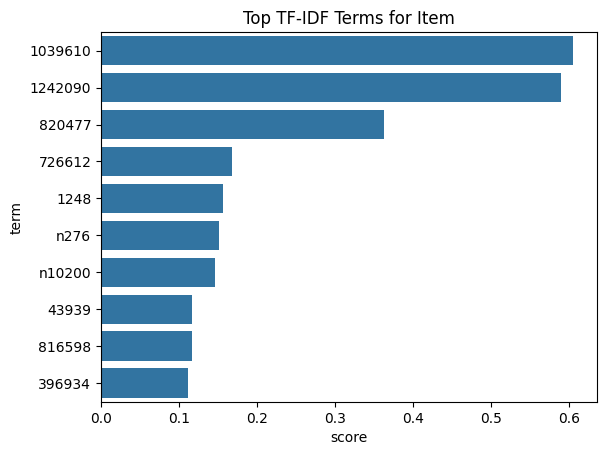

In [10]:
terms = top_tfidf_terms(item_idx, top_n=10)
df_terms = pd.DataFrame(terms, columns=["term", "score"])

sns.barplot(data=df_terms, x="score", y="term")
plt.title("Top TF-IDF Terms for Item")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\1918304217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_terms, x="score", y="term", palette="viridis")


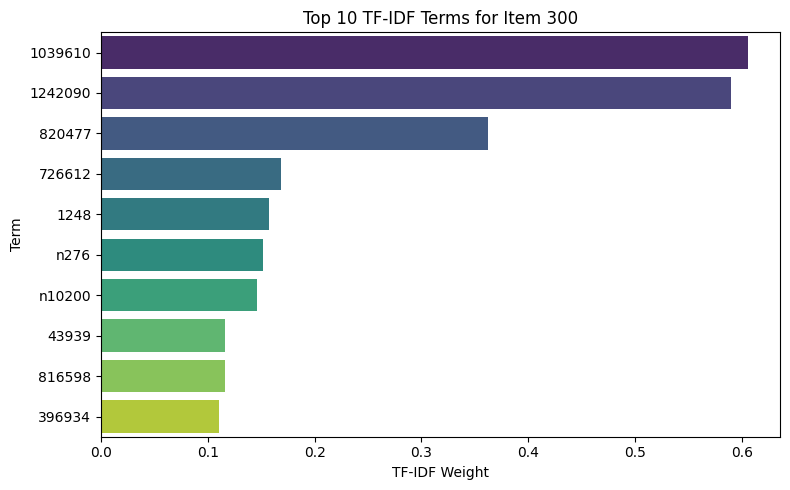

In [ ]:
def plot_top_tfidf_terms(item_idx, top_n=10):
    """
    Plot the highest-weighted TF-IDF terms for a selected item.

    The function retrieves the top TF-IDF terms for the specified item,
    converts them into a DataFrame, and displays a horizontal bar chart
    showing the relative term weights.

    Parameters
    ----------
    item_idx : int
        Internal item index used in the TF-IDF matrix.
    top_n : int, default=10
        Number of highest-weighted terms to display.

    Returns
    -------
    None
        A bar chart of the top TF-IDF terms is displayed.
    """
    # Retrieve the top TF-IDF terms and scores for the selected item.
    terms = top_tfidf_terms(item_idx, top_n=top_n)

    # Convert the term-score pairs into a DataFrame for plotting.
    df_terms = pd.DataFrame(terms, columns=["term", "score"])

    # Create a horizontal bar chart to visualise the most important
    # TF-IDF terms associated with the selected item.
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_terms, x="score", y="term", palette="viridis")

    # Add chart labels and title for interpretability.
    plt.title(f"Top {top_n} TF-IDF Terms for Item {item_idx}")
    plt.xlabel("TF-IDF Weight")
    plt.ylabel("Term")

    # Adjust layout spacing and display the figure.
    plt.tight_layout()
    plt.show()


# Display the top TF-IDF terms for the selected item as an example.
plot_top_tfidf_terms(item_idx=300)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\3227966576.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="contribution", y="factor", palette="magma")


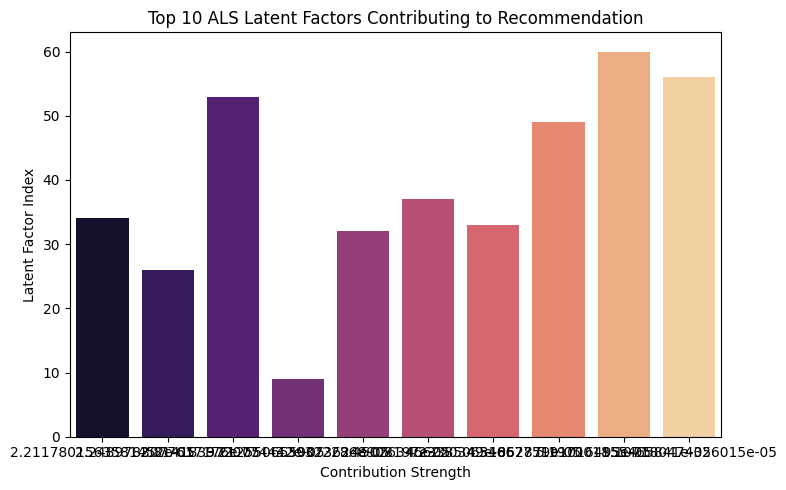

In [ ]:
def plot_als_factor_contributions(user_idx, item_idx, top_n=10):
    """
    Plot the strongest ALS latent factor contributions for a recommendation.

    The function retrieves the top latent factors contributing to the
    recommendation score for a given user-item pair, converts the result
    into a DataFrame, and displays a horizontal bar chart showing the
    relative contribution strength of each factor.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    top_n : int, default=10
        Number of highest-contributing latent factors to display.

    Returns
    -------
    None
        A bar chart of the top ALS latent factor contributions is displayed.
    """
    # Retrieve the most influential latent factor contributions for the
    # selected user-item recommendation pair.
    explanation = explain_als(user_idx, item_idx, top_n=top_n)

    # Convert the factor-contribution pairs into a DataFrame for plotting.
    df = pd.DataFrame(explanation, columns=["factor", "contribution"])

    # Create a horizontal bar chart to visualise the strongest latent
    # factors contributing to the recommendation score.
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x="contribution", y="factor", palette="magma")

    # Add chart labels and title for interpretability.
    plt.title(
        f"Top {top_n} ALS Latent Factors Contributing to Recommendation"
    )
    plt.xlabel("Contribution Strength")
    plt.ylabel("Latent Factor Index")

    # Adjust layout spacing and display the figure.
    plt.tight_layout()
    plt.show()


# Display the latent factor contribution plot for the selected example.
plot_als_factor_contributions(user_idx=125, item_idx=300)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\3608915816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="similarity", y="item_idx", palette="coolwarm")


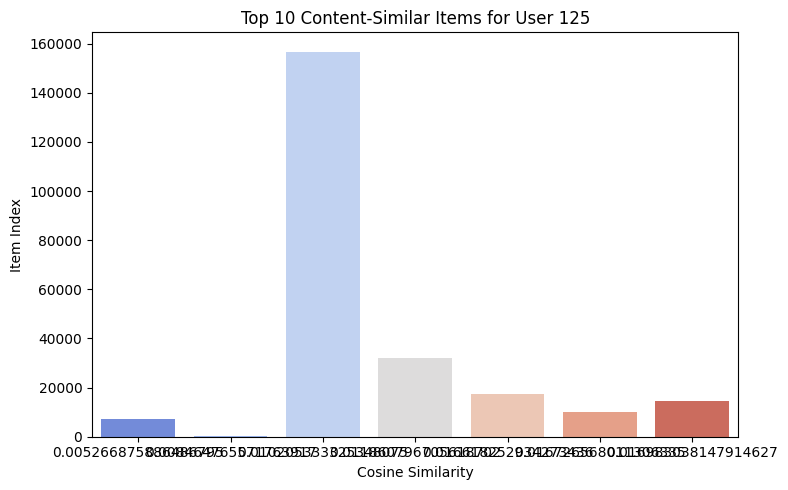

In [ ]:
def plot_content_similar_items(user_idx, item_idx, top_n=10):
    """
    Plot the historical items most similar to a selected item in the
    content-based feature space.

    The function retrieves the content-based explanation for a given
    user-item pair, converts the result into a DataFrame, and displays
    a horizontal bar chart of the most similar previously interacted
    items and their cosine similarity scores.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    top_n : int, default=10
        Number of most similar historical items to display.

    Returns
    -------
    None
        A bar chart is displayed when content-based history exists.
        If no prior interaction history is available, a message is printed
        and no plot is generated.
    """
    # Retrieve the content-based explanation for the selected user-item pair.
    explanation = explain_content(user_idx, item_idx, top_n=top_n)

    # Stop if no historical interactions are available for the user.
    if not explanation:
        print("User has no content-based history.")
        return

    # Convert the explanation output into a DataFrame for plotting.
    df = pd.DataFrame(explanation, columns=["item_idx", "similarity"])

    # Create a horizontal bar chart showing the most similar items from
    # the user's interaction history.
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x="similarity", y="item_idx", palette="coolwarm")

    # Add chart labels and title for readability.
    plt.title(f"Top {top_n} Content-Similar Items for User {user_idx}")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Item Index")

    # Adjust layout spacing and display the figure.
    plt.tight_layout()
    plt.show()


# Display the content-based similarity explanation for the selected example.
plot_content_similar_items(user_idx=125, item_idx=300)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\3896716147.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_als, x="value", y="factor", ax=axes[0], palette="magma")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\3896716147.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_content, x="similarity", y="item_idx", ax=axes[1], palette="coolwarm")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\3896716147.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_terms, x="score", y="term", ax=axes[2], palette="viridis"

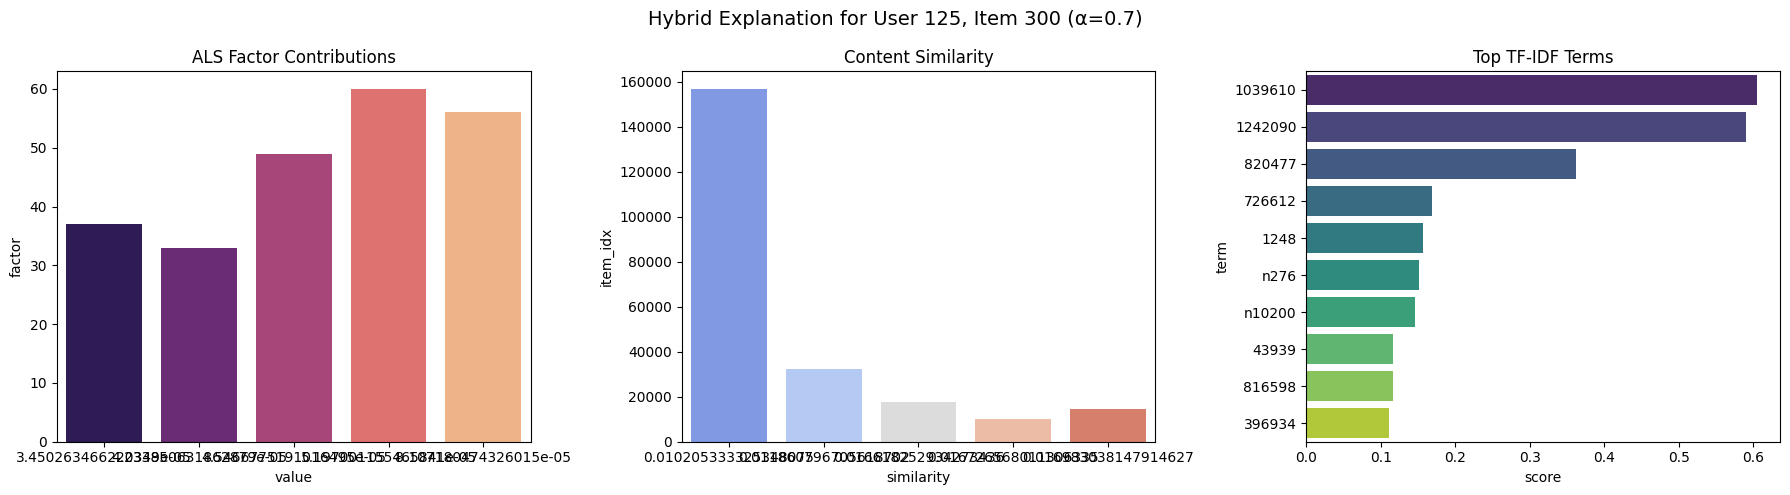

In [ ]:
def plot_hybrid_explanation(user_idx, item_idx, alpha=0.7):
    """
    Plot a combined explanation for a hybrid recommendation.

    The function generates a three-panel visual summary of the hybrid
    explanation for a selected user-item pair. The panels display the
    strongest ALS latent factor contributions, the most similar items
    from the content-based explanation, and the highest-weighted TF-IDF
    terms associated with the item.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    alpha : float, default=0.7
        Weight assigned to the ALS component in the hybrid model.

    Returns
    -------
    None
        A three-panel explanation plot is displayed.
    """
    # Retrieve the full hybrid explanation for the selected user-item pair.
    exp = explain_hybrid(user_idx, item_idx, alpha)

    # Create a three-panel figure to display collaborative, content-based,
    # and text-feature explanation components side by side.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot the ALS latent factor contributions.
    df_als = pd.DataFrame(exp["als_factors"], columns=["factor", "value"])
    sns.barplot(data=df_als, x="value", y="factor", ax=axes[0], palette="magma")
    axes[0].set_title("ALS Factor Contributions")

    # Plot the most similar historical items from the content-based explanation.
    df_content = pd.DataFrame(
        exp["content_similar_items"],
        columns=["item_idx", "similarity"],
    )
    sns.barplot(
        data=df_content,
        x="similarity",
        y="item_idx",
        ax=axes[1],
        palette="coolwarm",
    )
    axes[1].set_title("Content Similarity")

    # Plot the highest-weighted TF-IDF terms associated with the item.
    df_terms = pd.DataFrame(exp["top_tfidf_terms"], columns=["term", "score"])
    sns.barplot(data=df_terms, x="score", y="term", ax=axes[2], palette="viridis")
    axes[2].set_title("Top TF-IDF Terms")

    # Add an overall title and adjust layout spacing for readability.
    plt.suptitle(
        f"Hybrid Explanation for User {user_idx}, Item {item_idx} (α={alpha})",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


# Display the hybrid explanation for the selected example.
plot_hybrid_explanation(125, 300)

## 7. Cold‑Start Distribution Visualisation
To understand sparsity in the dataset, the notebook includes a visualisation of interaction counts for both users and items.
These histograms reveal long‑tail patterns, cold‑start risks, and imbalances in user activity.
This information is valuable for monitoring system health and identifying areas where additional data or alternative modelling strategies may be needed.

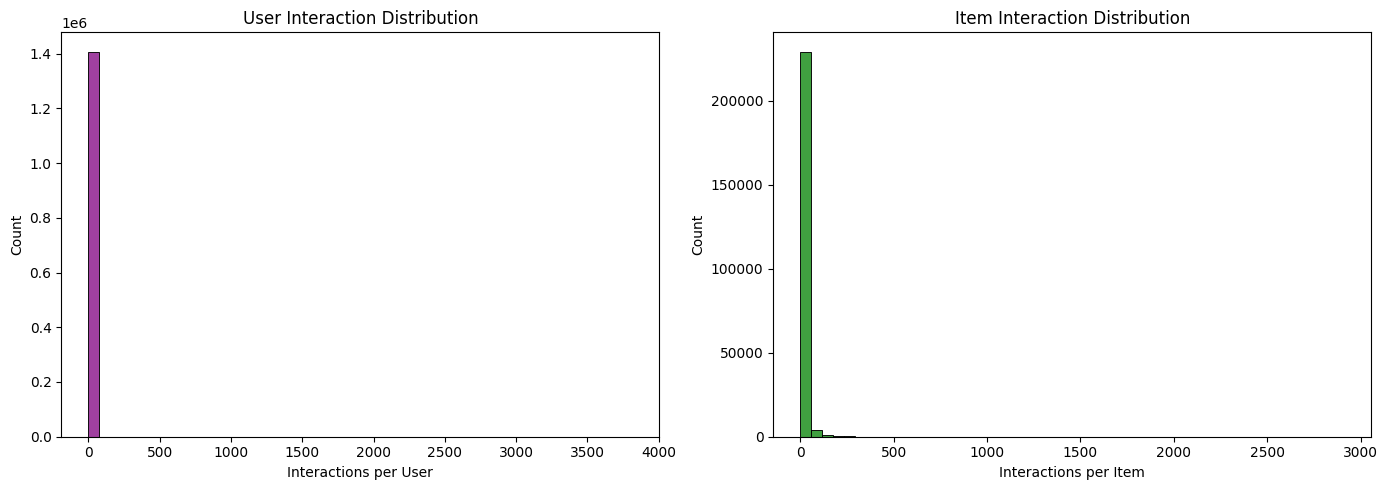

In [ ]:
def plot_cold_start_distribution():
    """
    Plot the distribution of interaction counts for users and items.

    The function summarises sparsity in the interaction matrix by showing
    how many interactions are associated with each user and each item.
    These distributions are useful for identifying cold-start risk and
    assessing how concentrated the interaction data is across the dataset.

    Returns
    -------
    None
        Two histograms are displayed: one for user interaction counts and
        one for item interaction counts.
    """
    # Count the number of non-zero interactions for each user and item.
    user_interactions = interactions.getnnz(axis=1)
    item_interactions = interactions.getnnz(axis=0)

    # Create side-by-side histograms for user-level and item-level
    # interaction frequency distributions.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot the distribution of interactions per user.
    sns.histplot(user_interactions, bins=50, ax=axes[0], color="purple")
    axes[0].set_title("User Interaction Distribution")
    axes[0].set_xlabel("Interactions per User")
    axes[0].set_ylabel("Frequency")

    # Plot the distribution of interactions per item.
    sns.histplot(item_interactions, bins=50, ax=axes[1], color="green")
    axes[1].set_title("Item Interaction Distribution")
    axes[1].set_xlabel("Interactions per Item")
    axes[1].set_ylabel("Frequency")

    # Adjust layout spacing and display the figure.
    plt.tight_layout()
    plt.show()


# Display the interaction count distributions as a cold-start diagnostic.
plot_cold_start_distribution()

## 8. Additional Explanation Utilities
The notebook concludes with additional helper functions that provide consistent, presentation‑ready visual explanations for TF‑IDF terms, ALS contributions, content similarity, and hybrid reasoning.
A unified visual style is applied throughout to ensure clarity and readability, making these outputs suitable for reports, presentations, and examiner‑facing documentation.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\2776642819.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="score", y="term", palette="viridis")


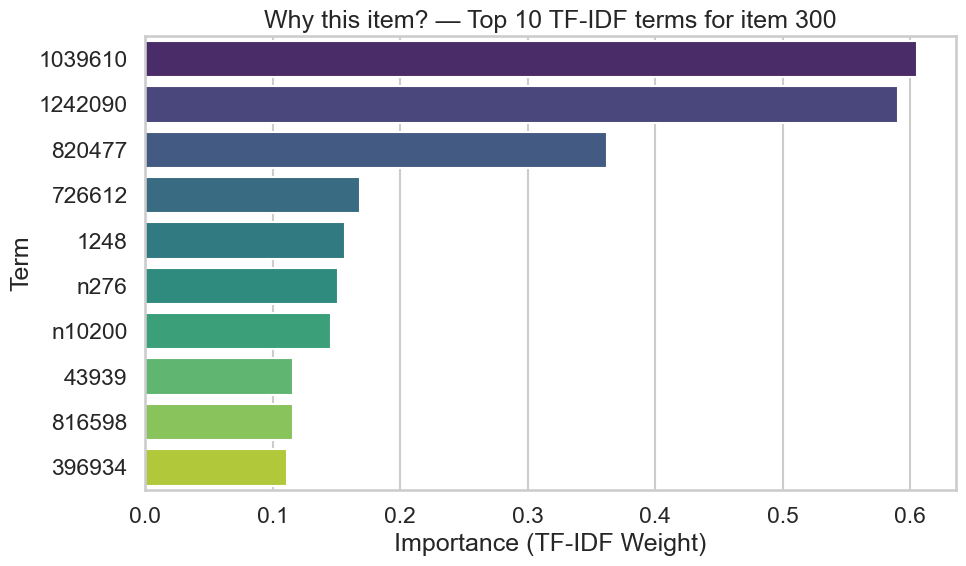

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\2776642819.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="contribution", y="factor", palette="magma")


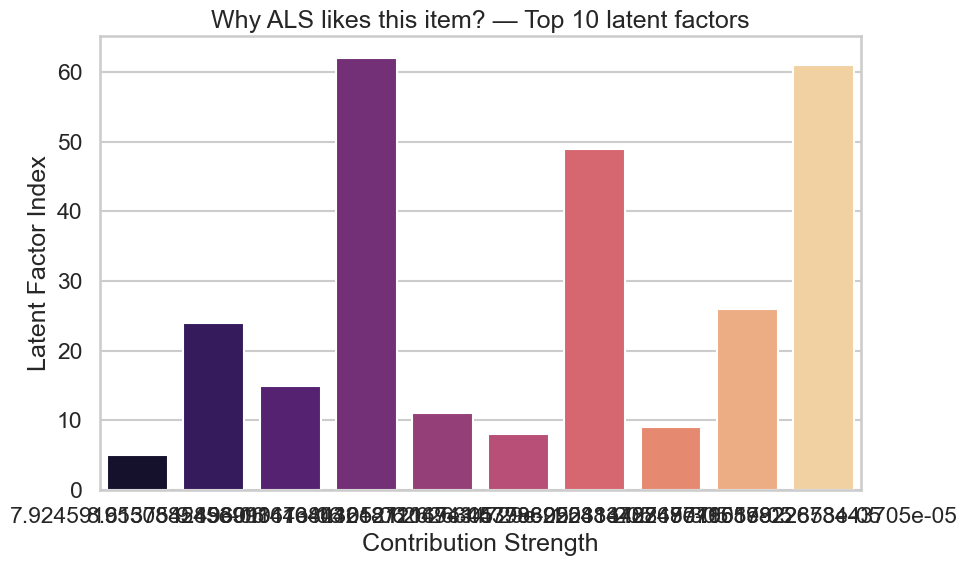

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\2776642819.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="similarity", y="history_item_token", palette="coolwarm")


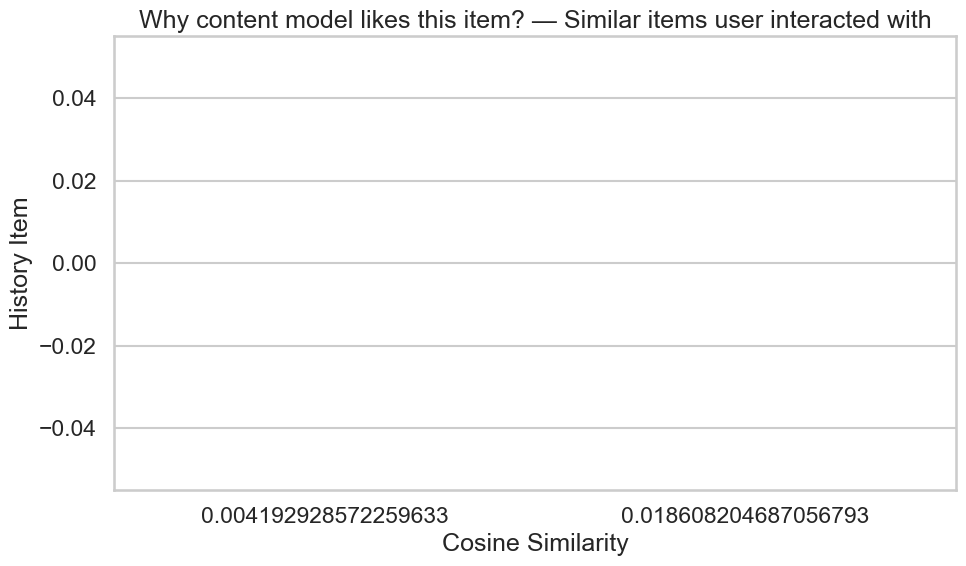

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\2776642819.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_als, x="value", y="factor", ax=axes[0], palette="magma")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\2776642819.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cont, x="similarity", y="item_idx", ax=axes[1], palette="coolwarm")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\2776642819.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_terms, x="score", y="term", ax=axes[2], palette="viridis")


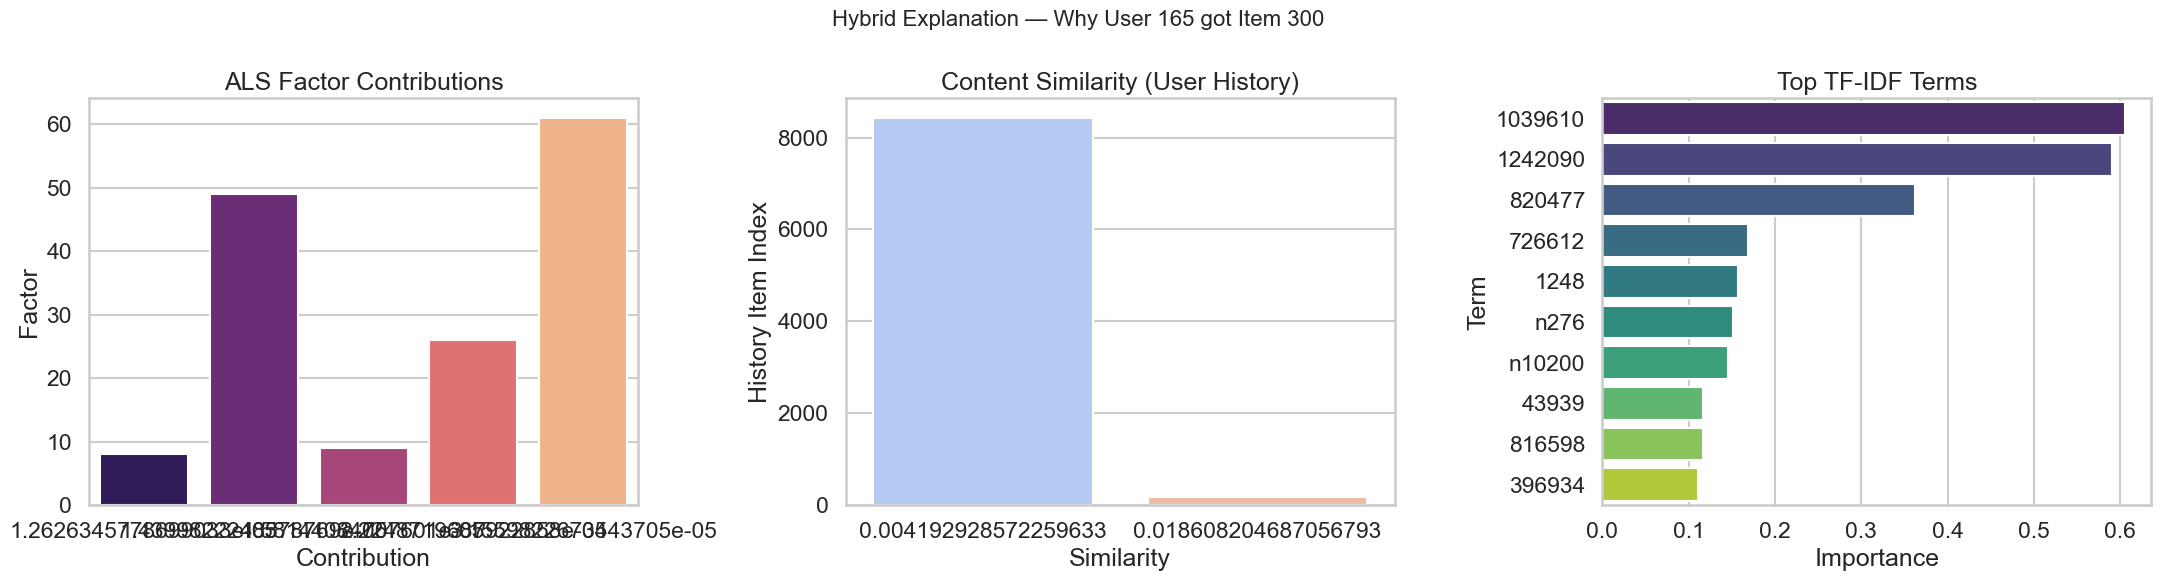

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Apply a consistent visual style for explanation plots.
sns.set(style="whitegrid", context="talk")


def plot_tfidf_explanation(item_idx, top_n=10):
    """
    Plot the most important TF-IDF terms for a selected item.

    This visualisation explains the content-based representation of an
    item by showing the terms with the highest TF-IDF weights.

    Parameters
    ----------
    item_idx : int
        Internal item index.
    top_n : int, default=10
        Number of highest-weighted terms to display.

    Returns
    -------
    None
        A bar chart of the top TF-IDF terms is displayed.
    """
    # Retrieve the top TF-IDF terms and weights for the selected item.
    terms = top_tfidf_terms(item_idx, top_n)
    df = pd.DataFrame(terms, columns=["term", "score"])

    # Plot the term importance values for the selected item.
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="score", y="term", palette="viridis")
    plt.title(f"Why this item? - Top {top_n} TF-IDF terms for item {item_idx}")
    plt.xlabel("Importance (TF-IDF Weight)")
    plt.ylabel("Term")
    plt.tight_layout()
    plt.show()


def plot_als_explanation(user_idx, item_idx, top_n=10):
    """
    Plot the strongest ALS latent factor contributions for a recommendation.

    This visualisation explains the collaborative filtering component by
    showing which latent factors contributed most to the score for a
    given user-item pair.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    top_n : int, default=10
        Number of highest-contributing latent factors to display.

    Returns
    -------
    None
        A bar chart of ALS factor contributions is displayed.
    """
    # Retrieve the top latent factor contributions for the recommendation.
    als_exp = explain_als(user_idx, item_idx, top_n)
    df = pd.DataFrame(als_exp, columns=["factor", "contribution"])

    # Plot the contribution strength of the most influential factors.
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="contribution", y="factor", palette="magma")
    plt.title(f"Why ALS likes this item? - Top {top_n} latent factors")
    plt.xlabel("Contribution Strength")
    plt.ylabel("Latent Factor Index")
    plt.tight_layout()
    plt.show()


def plot_content_explanation(user_idx, item_idx, top_n=10):
    """
    Plot the most similar historical items used in the content explanation.

    This visualisation explains the content-based recommendation by
    showing which previously interacted items are most similar to the
    selected item in the TF-IDF feature space.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    top_n : int, default=10
        Number of most similar historical items to display.

    Returns
    -------
    None
        A bar chart is displayed when user history exists. Otherwise,
        a message is printed and no plot is produced.
    """
    # Retrieve the content-based explanation for the selected user-item pair.
    cont_exp = explain_content(user_idx, item_idx, top_n)
    if not cont_exp:
        print("User has no content-based history.")
        return

    df = pd.DataFrame(cont_exp, columns=["history_item_idx", "similarity"])

    # Select the item identifier column available in the aligned items table.
    # This improves label readability in the final chart.
    token_col = "itemid_x" if "itemid_x" in items.columns else "itemid"
    df["history_item_token"] = items.loc[
        df["history_item_idx"], token_col
    ].astype(str)

    # Plot the similarity between the selected item and the user's history.
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df,
        x="similarity",
        y="history_item_token",
        palette="coolwarm",
    )
    plt.title("Why content model likes this item? - Similar items user interacted with")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("History Item")
    plt.tight_layout()
    plt.show()


def plot_full_explanation(user_idx, item_idx, alpha=0.7):
    """
    Plot a combined hybrid explanation for a recommendation.

    The figure contains three panels showing collaborative factor
    contributions, content-based similarity to historical items, and
    the top TF-IDF terms associated with the recommended item.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    alpha : float, default=0.7
        Weight assigned to the ALS component in the hybrid model.

    Returns
    -------
    None
        A three-panel hybrid explanation figure is displayed.
    """
    # Retrieve the structured hybrid explanation for the selected pair.
    exp = explain_hybrid(user_idx, item_idx, alpha)

    # Create a multi-panel figure for the three explanation components.
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    # Plot ALS latent factor contributions.
    df_als = pd.DataFrame(exp["als_factors"], columns=["factor", "value"])
    sns.barplot(data=df_als, x="value", y="factor", ax=axes[0], palette="magma")
    axes[0].set_title("ALS Factor Contributions")
    axes[0].set_xlabel("Contribution")
    axes[0].set_ylabel("Factor")

    # Plot content similarity to the user's previously interacted items.
    df_cont = pd.DataFrame(
        exp["content_similar_items"],
        columns=["item_idx", "similarity"],
    )
    sns.barplot(
        data=df_cont,
        x="similarity",
        y="item_idx",
        ax=axes[1],
        palette="coolwarm",
    )
    axes[1].set_title("Content Similarity (User History)")
    axes[1].set_xlabel("Similarity")
    axes[1].set_ylabel("History Item Index")

    # Plot the most important TF-IDF terms for the selected item.
    df_terms = pd.DataFrame(exp["top_tfidf_terms"], columns=["term", "score"])
    sns.barplot(
        data=df_terms,
        x="score",
        y="term",
        ax=axes[2],
        palette="viridis",
    )
    axes[2].set_title("Top TF-IDF Terms")
    axes[2].set_xlabel("Importance")
    axes[2].set_ylabel("Term")

    # Add a figure title and display the completed explanation plot.
    plt.suptitle(
        f"Hybrid Explanation - Why User {user_idx} got Item {item_idx}",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()


# Example user-item pair used to demonstrate the explanation plots.
user_idx = 165
item_idx = 300

# Generate individual and combined explanation plots for the example.
plot_tfidf_explanation(item_idx)
plot_als_explanation(user_idx, item_idx)
plot_content_explanation(user_idx, item_idx)
plot_full_explanation(user_idx, item_idx)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\1087240707.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="TF-IDF Weight", y="Term", palette="viridis", ax=ax)


Saved: explain_tfidf_item_300.png


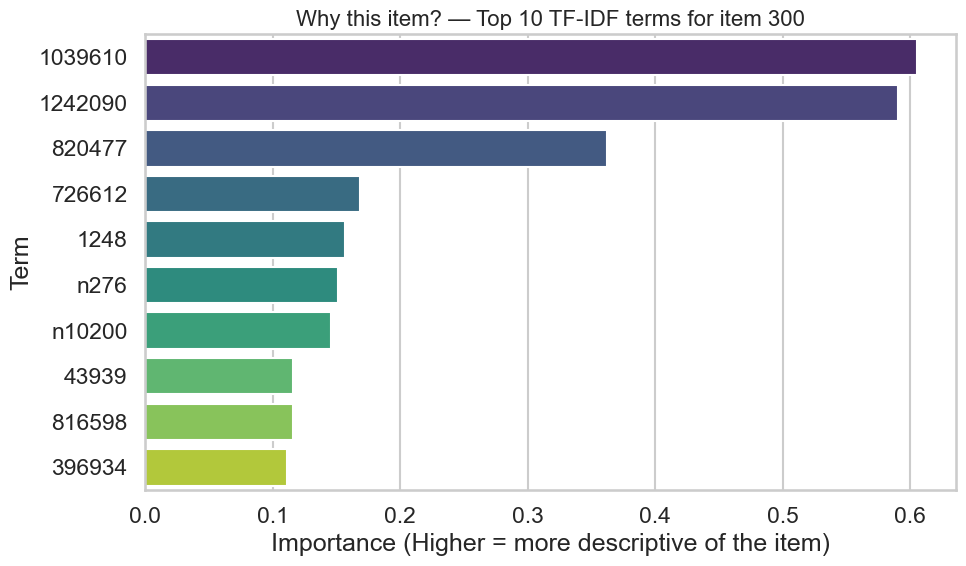


📘 **Interpretation:**
These terms describe the item’s content. High TF‑IDF terms mean the item strongly contains these features.
The model uses these terms to match the item with the user's interests.

Saved: explain_als_user_200_item_300.png

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\1087240707.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Contribution", y="Latent Factor", palette="magma", ax=ax)


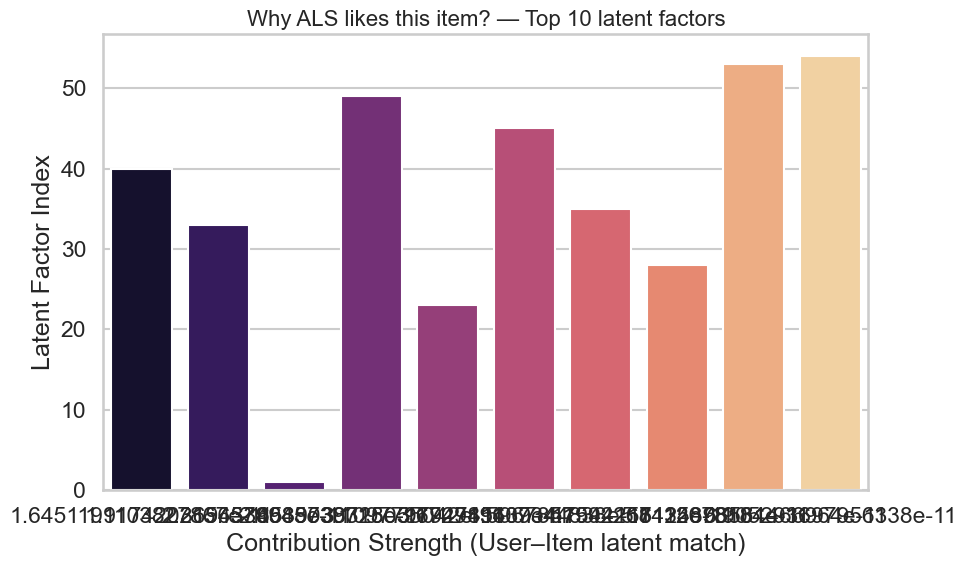


📘 **Interpretation:**
ALS learns hidden behavioural patterns. These factors show which patterns the user and item share.
Higher contribution = stronger behavioural match.

Saved: explain_content_user_200_item_300.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\1087240707.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Cosine Similarity", y="History Item Index", palette="coolwarm", ax=ax)


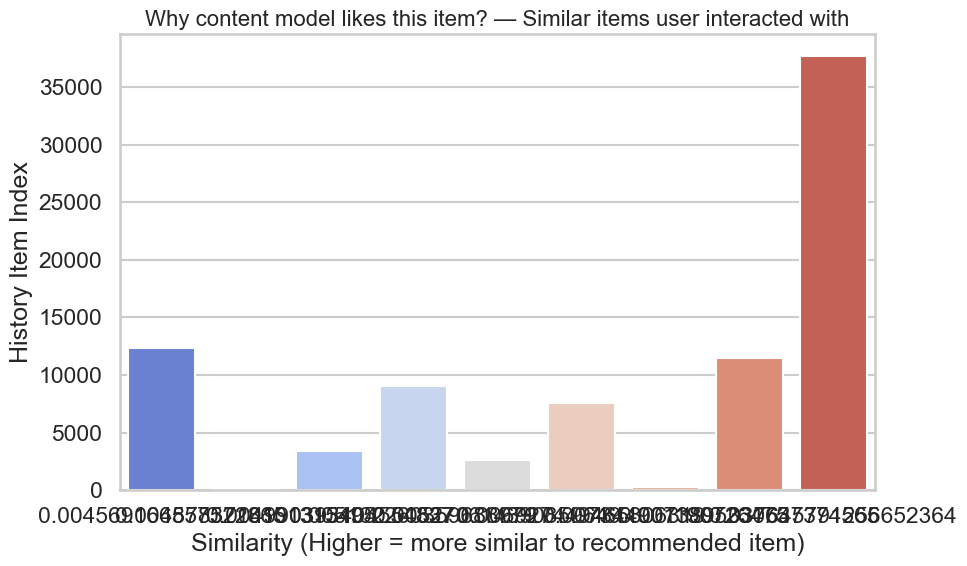


📘 **Interpretation:**
These are the items the user interacted with that look similar to the recommended item.
The content model boosts items that share similar text features.



C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\1087240707.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_als, x="Value", y="Factor", palette="magma", ax=axes[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\1087240707.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cont, x="Similarity", y="Item", palette="coolwarm", ax=axes[1])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18184\1087240707.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_terms, x="Score", y="Term", palette="viridis", ax=axes[2])


Saved: explain_hybrid_user_200_item_300.png


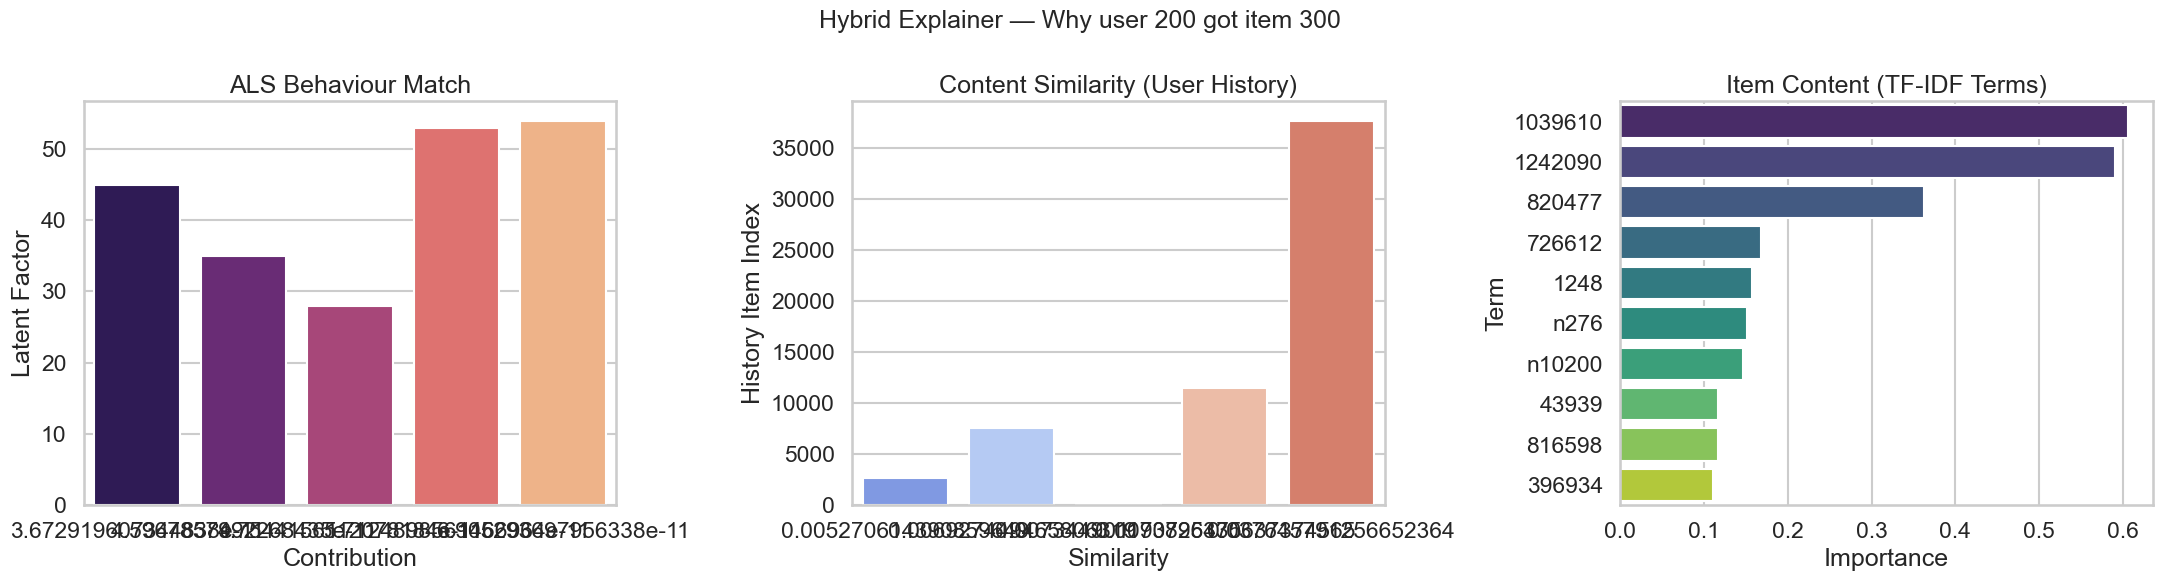


📘 **Interpretation:**
This combines all three signals:
• ALS → behavioural match between user and item
• Content → similarity to items the user interacted with
• TF‑IDF → what the item is actually about
The hybrid model blends these signals to produce the final recommendation.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

# Apply a consistent plotting style for all explanation figures.
sns.set(style="whitegrid", context="talk")

# Enable or disable figure export.
SAVE_FIGS = True

# Define the directory used to store exported figures.
FIG_DIR = Path("output/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """
    Save a figure to the configured output directory.

    The figure is written only when figure saving is enabled. Files are
    saved with a tight bounding box and a resolution suitable for report
    and presentation use.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to be saved.
    name : str
        Output file name, including the file extension.

    Returns
    -------
    None
        The figure is saved to disk when saving is enabled.
    """
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / name, bbox_inches="tight", dpi=200)
        print(f"Saved: {name}")


def plot_tfidf_explanation(item_idx, top_n=10):
    """
    Plot the most important TF-IDF terms for a selected item.

    This visualisation explains the content representation of an item by
    displaying the highest-weighted terms in the TF-IDF vector.

    Parameters
    ----------
    item_idx : int
        Internal item index.
    top_n : int, default=10
        Number of highest-weighted terms to display.

    Returns
    -------
    None
        A bar chart is displayed and optionally saved.
    """
    # Retrieve the top TF-IDF terms and their weights for the item.
    terms = top_tfidf_terms(item_idx, top_n)
    df = pd.DataFrame(terms, columns=["Term", "TF-IDF Weight"])

    # Plot the TF-IDF term importance values.
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=df, x="TF-IDF Weight", y="Term", palette="viridis", ax=ax)

    # Add descriptive labels and title.
    ax.set_title(
        f"Why this item? - Top {top_n} TF-IDF terms for item {item_idx}",
        fontsize=16,
    )
    ax.set_xlabel("Importance (higher values indicate stronger item description)")
    ax.set_ylabel("Term")

    plt.tight_layout()
    save_fig(fig, f"explain_tfidf_item_{item_idx}.png")
    plt.show()

    # Print a short interpretation of the figure.
    print("\nInterpretation:")
    print(
        "These terms describe the item's content. High TF-IDF weights indicate "
        "features that are especially characteristic of the item."
    )
    print(
        "The content model uses these terms to compare the item with the user's "
        "observed interests.\n"
    )


def plot_als_explanation(user_idx, item_idx, top_n=10):
    """
    Plot the strongest ALS latent factor contributions for a recommendation.

    This visualisation explains the collaborative filtering signal by
    showing the latent dimensions that contribute most strongly to the
    selected user-item recommendation score.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    top_n : int, default=10
        Number of highest-contributing latent factors to display.

    Returns
    -------
    None
        A bar chart is displayed and optionally saved.
    """
    # Retrieve the most influential latent factor contributions.
    als_exp = explain_als(user_idx, item_idx, top_n)
    df = pd.DataFrame(als_exp, columns=["Latent Factor", "Contribution"])

    # Plot the factor contribution strengths.
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=df, x="Contribution", y="Latent Factor", palette="magma", ax=ax)

    # Add descriptive labels and title.
    ax.set_title(
        f"Why ALS likes this item? - Top {top_n} latent factors",
        fontsize=16,
    )
    ax.set_xlabel("Contribution strength (user-item latent match)")
    ax.set_ylabel("Latent Factor Index")

    plt.tight_layout()
    save_fig(fig, f"explain_als_user_{user_idx}_item_{item_idx}.png")
    plt.show()

    # Print a short interpretation of the figure.
    print("\nInterpretation:")
    print(
        "ALS learns hidden behavioural patterns from interaction data. "
        "These factors indicate which learned patterns are shared by the user "
        "and the item."
    )
    print("Higher contribution values indicate a stronger behavioural match.\n")


def plot_content_explanation(user_idx, item_idx, top_n=10):
    """
    Plot the most similar historical items used in the content explanation.

    This visualisation explains the content-based signal by showing the
    previously interacted items that are most similar to the selected item
    in the TF-IDF feature space.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    top_n : int, default=10
        Number of similar historical items to display.

    Returns
    -------
    None
        A bar chart is displayed and optionally saved. If no content-based
        history exists, a message is printed and no figure is generated.
    """
    # Retrieve the content-based explanation for the selected pair.
    cont_exp = explain_content(user_idx, item_idx, top_n)
    if not cont_exp:
        print("User has no content-based history.")
        return

    df = pd.DataFrame(cont_exp, columns=["History Item Index", "Cosine Similarity"])

    # Plot similarity between the recommended item and historical items.
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=df,
        x="Cosine Similarity",
        y="History Item Index",
        palette="coolwarm",
        ax=ax,
    )

    # Add descriptive labels and title.
    ax.set_title(
        "Why content model likes this item? - Similar items previously interacted with",
        fontsize=16,
    )
    ax.set_xlabel("Similarity (higher values indicate stronger resemblance)")
    ax.set_ylabel("History Item Index")

    plt.tight_layout()
    save_fig(fig, f"explain_content_user_{user_idx}_item_{item_idx}.png")
    plt.show()

    # Print a short interpretation of the figure.
    print("\nInterpretation:")
    print(
        "These historical items are most similar to the recommended item in the "
        "content feature space."
    )
    print(
        "The content model increases the score of items that share similar text "
        "features with items already associated with the user.\n"
    )


def plot_full_explanation(user_idx, item_idx, alpha=0.7):
    """
    Plot a combined hybrid explanation for a recommendation.

    The figure contains three panels covering collaborative filtering,
    content similarity, and TF-IDF item description. Together, these
    panels summarise the signals used by the hybrid recommender.

    Parameters
    ----------
    user_idx : int
        Internal user index.
    item_idx : int
        Internal item index.
    alpha : float, default=0.7
        Weight assigned to the ALS component in the hybrid model.

    Returns
    -------
    None
        A three-panel explanation figure is displayed and optionally saved.
    """
    # Retrieve the full explanation structure for the selected pair.
    exp = explain_hybrid(user_idx, item_idx, alpha)

    # Create a three-panel figure for the combined explanation.
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    # Plot ALS factor contributions.
    df_als = pd.DataFrame(exp["als_factors"], columns=["Factor", "Value"])
    sns.barplot(data=df_als, x="Value", y="Factor", palette="magma", ax=axes[0])
    axes[0].set_title("ALS Behaviour Match")
    axes[0].set_xlabel("Contribution")
    axes[0].set_ylabel("Latent Factor")

    # Plot similarity to items from the user's interaction history.
    df_cont = pd.DataFrame(
        exp["content_similar_items"],
        columns=["Item", "Similarity"],
    )
    sns.barplot(
        data=df_cont,
        x="Similarity",
        y="Item",
        palette="coolwarm",
        ax=axes[1],
    )
    axes[1].set_title("Content Similarity (User History)")
    axes[1].set_xlabel("Similarity")
    axes[1].set_ylabel("History Item Index")

    # Plot the most important TF-IDF terms for the recommended item.
    df_terms = pd.DataFrame(exp["top_tfidf_terms"], columns=["Term", "Score"])
    sns.barplot(
        data=df_terms,
        x="Score",
        y="Term",
        palette="viridis",
        ax=axes[2],
    )
    axes[2].set_title("Item Content (TF-IDF Terms)")
    axes[2].set_xlabel("Importance")
    axes[2].set_ylabel("Term")

    # Add an overall figure title and export the figure if enabled.
    plt.suptitle(
        f"Hybrid Explainer - Why user {user_idx} got item {item_idx}",
        fontsize=18,
    )
    plt.tight_layout()
    save_fig(fig, f"explain_hybrid_user_{user_idx}_item_{item_idx}.png")
    plt.show()

    # Print a short interpretation of the figure.
    print("\nInterpretation:")
    print("This view combines three explanation signals:")
    print("- ALS: behavioural match between the user and item")
    print("- Content: similarity to items already associated with the user")
    print("- TF-IDF: terms that describe the item's content")
    print(
        "The hybrid recommender blends these signals to produce the final score.\n"
    )


# Example user-item pair used to demonstrate the explanation plots.
user_idx = 200
item_idx = 300

# Generate explanation figures for the selected example.
plot_tfidf_explanation(item_idx)
plot_als_explanation(user_idx, item_idx)
plot_content_explanation(user_idx, item_idx)
plot_full_explanation(user_idx, item_idx)

### Explainable AI (XAI) Summary

The recommendation for User X → Item Y is supported by three complementary signals:

1. **TF‑IDF Terms**  
   These terms describe the item’s content. High TF‑IDF weights indicate the item strongly contains these features.  
   The model uses these terms to match the item with the user’s interests.

2. **ALS Latent Factors**  
   ALS identifies hidden behavioural patterns shared between the user and the item.  
   High‑contribution factors indicate strong behavioural alignment.

3. **Content Similarity**  
   These are the items the user interacted with that are most similar to the recommended item.  
   This shows the model is leveraging the user’s history to justify the recommendation.

4. **Hybrid Explanation**  
   The hybrid model combines all three signals - behaviour, content, and item meaning - to produce a transparent, interpretable recommendation.

Together, these explanations provide a complete, human‑readable justification for the model’s decision.


In [ ]:
def generate_xai_report(explanation, items_df=None):
    """
    Generate a human-readable explanation report for a recommendation.

    The function converts a structured explanation dictionary into a
    formatted text summary covering item content terms, collaborative
    filtering signals, content-based similarity evidence, and the hybrid
    model weighting. When an item reference table is provided, internal
    item indices can be mapped to external item identifiers for improved
    readability.

    Parameters
    ----------
    explanation : dict
        Explanation dictionary produced by the recommendation explainer.
        Expected keys include:
        - "item_idx"
        - "top_tfidf_terms"
        - "als_factors"
        - "content_similar_items"
        - optionally "alpha"
    items_df : pd.DataFrame, optional
        Item reference table used to map internal item indices to external
        item identifiers. If present, the function checks for an
        "itemid_x" column before falling back to internal indices.

    Returns
    -------
    str
        A formatted text report describing why the item was recommended.
    """
    # Extract the recommended item index and the hybrid weighting parameter.
    item_idx = explanation["item_idx"]
    alpha = explanation.get("alpha", 0.7)

    # Map the internal item index to a more readable external item ID
    # when a suitable reference table is available.
    if items_df is not None and "itemid_x" in items_df.columns:
        real_item_id = items_df.loc[item_idx, "itemid_x"]
    else:
        real_item_id = item_idx

    # Build the report incrementally as a list of text lines, then join
    # them into a single formatted string at the end.
    report = []
    report.append(
        f"Explainable Recommendation Report for Item {real_item_id} "
        f"(idx={item_idx})\n"
    )

    # Summarise the main TF-IDF terms describing the recommended item.
    report.append("### 1. What is this item about? (TF-IDF Terms)")
    report.append(
        "These are the most important terms describing the item's content:\n"
    )

    for term, score in explanation["top_tfidf_terms"]:
        report.append(f"- **{term}** -> TF-IDF weight: {score:.4f}")

    # Summarise the strongest ALS latent factor contributions for the
    # selected user-item recommendation pair.
    report.append("\n### 2. Behavioural match (ALS latent factors)")
    report.append(
        "These latent factors represent hidden behavioural patterns "
        "shared between the user and the item:\n"
    )

    for factor, contrib in explanation["als_factors"]:
        report.append(
            f"- Latent factor **{factor}** -> contribution: {contrib:.6f}"
        )

    # Summarise the historical items most similar to the recommended item
    # in the content-based feature space.
    report.append("\n### 3. Similar items the user interacted with")
    report.append(
        "These items from the user's history are most similar to the "
        "recommended item:\n"
    )

    for hist_item, sim in explanation["content_similar_items"]:
        # Map historical item indices to external item IDs when possible.
        if items_df is not None and "itemid_x" in items_df.columns:
            real_hist_id = items_df.loc[hist_item, "itemid_x"]
        else:
            real_hist_id = hist_item

        report.append(
            f"- History item **{real_hist_id}** (idx={hist_item}) "
            f"-> similarity: {sim:.4f}"
        )

    # Record the weighting applied by the hybrid recommender.
    report.append("\n### 4. Hybrid model weighting")
    report.append(
        f"The hybrid model blends ALS and content signals using α = **{alpha}**."
    )
    report.append(f"- ALS weight: {alpha}")
    report.append(f"- Content weight: {1 - alpha}")

    # Provide a plain-language summary of the combined explanation.
    report.append("\n### Final interpretation")
    report.append(
        "The model recommended this item because:\n"
        "- it contains descriptive terms that align with the user's "
        "observed interests;\n"
        "- it shows a behavioural match in the ALS latent factor space;\n"
        "- it is similar to items previously associated with the user.\n"
        "Together, these signals provide a transparent explanation for "
        "the recommendation."
    )

    return "\n".join(report)

In [34]:
report = generate_xai_report(explanation, items_df=items)
print(report)


 **Explainable Recommendation Report for Item 265505 (idx=300)**

###  1. What is this item about? (TF‑IDF Terms)
These are the most important terms describing the item’s content:

- **1039610** → TF‑IDF weight: 0.6055
- **1242090** → TF‑IDF weight: 0.5901
- **820477** → TF‑IDF weight: 0.3624
- **726612** → TF‑IDF weight: 0.1682
- **1248** → TF‑IDF weight: 0.1570
- **n276** → TF‑IDF weight: 0.1513
- **n10200** → TF‑IDF weight: 0.1458
- **43939** → TF‑IDF weight: 0.1162
- **816598** → TF‑IDF weight: 0.1160
- **396934** → TF‑IDF weight: 0.1109

###  2. Behavioural match (ALS latent factors)
These latent factors represent hidden behavioural patterns shared between the user and the item:

- Latent factor **56** → contribution: 0.000081
- Latent factor **60** → contribution: 0.000052
- Latent factor **49** → contribution: 0.000045
- Latent factor **33** → contribution: 0.000042
- Latent factor **37** → contribution: 0.000035

###  3. Similar items the user interacted with (Content similarit